In [1]:
import pandas as pd
import pickle

In [3]:
# pred_dfs_path = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/evals/cluster_iat/vL_both_pred_dfs-PeskaVLP-include_none_label=100-label_count_filter=20.pkl'
pred_dfs_path = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/evals/cluster_iat/vL_both_pred_dfs_frame-PeskaVLP-include_none_label=100-label_count_filter=20.pkl'

with open(pred_dfs_path, 'rb') as f:
    pred_dfs = pickle.load(f)

In [4]:
keys = list(pred_dfs.keys())
instrument_df = pred_dfs[keys[0]]
action_df = pred_dfs[keys[1]]
tissue_df = pred_dfs[keys[2]]

cols = ['Dialogue', 'Timestamp', 'Case', 'label', 'pred']
instrument_df = instrument_df[cols]
action_df = action_df[cols]
tissue_df = tissue_df[cols]

instrument_df = instrument_df.rename(columns={'label': 'instrument-label', 'pred': 'instrument-pred'})
action_df = action_df.rename(columns={'label': 'action-label', 'pred': 'action-pred'})
tissue_df = tissue_df.rename(columns={'label': 'tissue-label', 'pred': 'tissue-pred'})

instrument_df['instrument-correct'] = instrument_df['instrument-label'] == instrument_df['instrument-pred']
action_df['action-correct'] = action_df['action-label'] == action_df['action-pred']
tissue_df['tissue-correct'] = tissue_df['tissue-label'] == tissue_df['tissue-pred']

merge_on_cols = ['Dialogue', 'Timestamp', 'Case']
merge_df = instrument_df.merge(action_df[merge_on_cols + ['action-label', 'action-pred', 'action-correct']], on=['Dialogue', 'Timestamp', 'Case'], how='outer')
merge_df = merge_df.merge(tissue_df[merge_on_cols + ['tissue-label', 'tissue-pred', 'tissue-correct']], on=['Dialogue', 'Timestamp', 'Case'], how='outer')

merge_df['valid'] = merge_df.apply(lambda row: True if False not in {row['instrument-correct'], row['action-correct'], row['tissue-correct']} else False, axis=1)

merge_df = merge_df.reset_index(drop=True)

In [5]:
valid_df = merge_df[merge_df['valid']].reset_index(drop=True)
print(f'Number of valid rows: {len(valid_df)}')

Number of valid rows: 476


In [7]:
import openai
import backoff
import json
import re
import pandas as pd
import numpy as np
import string
import random
import os

import sys
sys.path.append('..')
from utils import set_envvars
ENVVARS = set_envvars(constants_path='/home/firdavs/surgery/surgical_fb_generation/SurgFBGen/constants.json')

def init_OpenAI(key):
  client = openai.OpenAI(
    # This is the default and can be omitted
    api_key=key,
  )
  return client

def list_models(client):
  models = client.models.list()
  model_names = [model.id for model in models.data]
  return model_names

def generate_GPT(client, model_name, instruction, label_prompt, temperature=0.0):
  @backoff.on_exception(backoff.expo, (openai.RateLimitError,
                                       openai.APIError,
                                       ConnectionResetError,
                                       json.decoder.JSONDecodeError))

  def completions_with_backoff(**kwargs):
    return client.chat.completions.create(**kwargs)

  resp = []
  # Prompt OpenAI
  # https://github.com/openai/openai-python
  response = completions_with_backoff(model=model_name,
                                      temperature=temperature,
                                      messages=[{"role": "system", "content": instruction},
                                                {"role": "user",   "content": label_prompt}])

  gen = response.choices[0].message.content
  return gen

In [8]:
client = init_OpenAI(key=os.environ['OPENAI_API_KEY'])
available_models = list_models(client)
print(f'Available models: {available_models}')

Available models: ['gpt-4-0613', 'gpt-4', 'gpt-3.5-turbo', 'gpt-5-nano', 'gpt-5', 'gpt-5-mini-2025-08-07', 'gpt-5-mini', 'gpt-5-nano-2025-08-07', 'davinci-002', 'babbage-002', 'gpt-3.5-turbo-instruct', 'gpt-3.5-turbo-instruct-0914', 'dall-e-3', 'dall-e-2', 'gpt-4-1106-preview', 'gpt-3.5-turbo-1106', 'tts-1-hd', 'tts-1-1106', 'tts-1-hd-1106', 'text-embedding-3-small', 'text-embedding-3-large', 'gpt-4-0125-preview', 'gpt-4-turbo-preview', 'gpt-3.5-turbo-0125', 'gpt-4-turbo', 'gpt-4-turbo-2024-04-09', 'gpt-4o', 'gpt-4o-2024-05-13', 'gpt-4o-mini-2024-07-18', 'gpt-4o-mini', 'gpt-4o-2024-08-06', 'chatgpt-4o-latest', 'o1-mini-2024-09-12', 'o1-mini', 'gpt-4o-realtime-preview-2024-10-01', 'gpt-4o-audio-preview-2024-10-01', 'gpt-4o-audio-preview', 'gpt-4o-realtime-preview', 'omni-moderation-latest', 'omni-moderation-2024-09-26', 'gpt-4o-realtime-preview-2024-12-17', 'gpt-4o-audio-preview-2024-12-17', 'gpt-4o-mini-realtime-preview-2024-12-17', 'gpt-4o-mini-audio-preview-2024-12-17', 'o1-2024-12-1

In [8]:
add_history = False
num_history = 10

add_real_examples = False
num_examples = 10

use_gpt4o = True

# fb_generation_system_prompt_path = '../prompts/fb_generation-system.txt'
# fb_generation_system_prompt_path = '../prompts/fb_generation-system-no_2_6_criteria.txt'
# fb_generation_system_prompt_path = '../prompts/fb_generation-system-no_criteria.txt'
# fb_generation_system_prompt_path = '../prompts/fb_generation-system-short.txt'
fb_generation_system_prompt_path = '../prompts/fb_generation-system-no_criteria.txt'

fb_generation_user_prompt_path = '../prompts/fb_generation-user.txt'

if add_history:
    fb_generation_system_prompt_path = fb_generation_system_prompt_path.replace('.txt', '-history.txt')
    fb_generation_user_prompt_path = fb_generation_user_prompt_path.replace('.txt', '-history.txt')

if add_real_examples:
    fb_generation_system_prompt_path = fb_generation_system_prompt_path.replace('.txt', '-examples.txt')
    fb_generation_user_prompt_path = fb_generation_user_prompt_path.replace('.txt', '-examples.txt')

with open(fb_generation_system_prompt_path, 'r') as f:
    gen_instruction = f.read()
with open(fb_generation_user_prompt_path, 'r') as f:
    gen_label_prompt_template = f.read()

In [9]:
row = valid_df.iloc[0]
iat_triplet = (str(row['instrument-label']), str(row['action-label']), str(row['tissue-label']))

## Prepare input for OpenAI
# 1. Input IAT triplet
label_prompt = gen_label_prompt_template.replace('<INSTRUMENT>', iat_triplet[0])
label_prompt = label_prompt.replace('<ACTION>', iat_triplet[1])
label_prompt = label_prompt.replace('<TISSUE>', iat_triplet[2])

# (optional) 2. Add history
if add_history:
    history_fb_gen_df = pd.read_csv(f'../outputs/fb_generation/fb_gen_df-vl_both-PeskaVLP-{"gpt4o-" if use_gpt4o else ""}no_criteria.csv').iloc[1:].sample(10, random_state=42).reset_index(drop=True)
    history_str = ''
    for i in range(num_history):
        history_str += f"IAT(instrument: {history_fb_gen_df['instrument-label'].iloc[i]}, action: {history_fb_gen_df['action-label'].iloc[i]}, tissue: {history_fb_gen_df['tissue-label'].iloc[i]})"
        history_str += f" -> {history_fb_gen_df['generated_feedback'].iloc[i]}\n"
    label_prompt = label_prompt.replace('<HISTORY>', history_str)
    
if add_real_examples:
    real_examples_str = ''
    for i in range(num_examples):
        real_examples_str += f"IAT(instrument: {valid_df['instrument-label'].iloc[i]}, action: {valid_df['action-label'].iloc[i]}, tissue: {valid_df['tissue-label'].iloc[i]})"
        real_examples_str += f" -> {valid_df['Dialogue'].iloc[i]}\n"    
    label_prompt = label_prompt.replace('<EXAMPLES>', real_examples_str)

print(label_prompt)

IAT Triplet:
instrument: suturing_tools, action: nan, tissue: nan

Feedback:



In [10]:
fb = generate_GPT(client, model_name='gpt-4o', instruction=gen_instruction, label_prompt=label_prompt, temperature=0.0)

In [11]:
fb

'Ensure suturing tools are ready for the next step.'

In [12]:
valid_df['iat_triplet'] = valid_df.apply(lambda row: (str(row['instrument-label']), str(row['action-label']), str(row['tissue-label'])), axis=1)
valid_df['label_prompt'] = valid_df['iat_triplet'].apply(lambda x: gen_label_prompt_template.replace('<INSTRUMENT>', x[0]).replace('<ACTION>', x[1]).replace('<TISSUE>', x[2]))

def add_history_to_label_prompt(label_prompt, history_df, num_history, curr_idx):
    history_df = history_df.copy()
    history_df = history_df.drop(history_df.iloc[[curr_idx]].index) 
    history_df = history_df.sample(10, random_state=curr_idx).reset_index(drop=True)
    history_str = ''
    for i in range(num_history):
        history_str += f"IAT(instrument: {history_df['instrument-label'].iloc[i]}, action: {history_df['action-label'].iloc[i]}, tissue: {history_df['tissue-label'].iloc[i]})"
        history_str += f" -> {history_df['generated_feedback'].iloc[i]}\n"
    return label_prompt.replace('<HISTORY>', history_str)

def add_examples_to_label_prompt(label_prompt, valid_df, num_examples):
    real_examples_str = ''
    for i in range(num_examples):
        real_examples_str += f"IAT(instrument: {valid_df['instrument-label'].iloc[i]}, action: {valid_df['action-label'].iloc[i]}, tissue: {valid_df['tissue-label'].iloc[i]})"
        real_examples_str += f" -> {valid_df['Dialogue'].iloc[i]}\n"    
    return label_prompt.replace('<EXAMPLES>', real_examples_str)


# Add history to the label prompt
if add_history:
    history_fb_gen_df = pd.read_csv(f'../outputs/fb_generation/fb_gen_df-vl_both-PeskaVLP-{"gpt4o-" if use_gpt4o else ""}no_criteria.csv')
    for i in range(len(valid_df)):
        valid_df.at[i, 'label_prompt'] = add_history_to_label_prompt(valid_df.at[i, 'label_prompt'], history_fb_gen_df, num_history, i)

if add_real_examples:
    for i in range(len(valid_df)):
        valid_df.at[i, 'label_prompt'] = add_examples_to_label_prompt(valid_df.at[i, 'label_prompt'], valid_df, num_examples)

In [13]:
print(valid_df.head().iloc[0]['label_prompt'])

IAT Triplet:
instrument: suturing_tools, action: nan, tissue: nan

Feedback:



In [14]:
from tqdm import tqdm
# model = 'gpt-4.1-mini' 
model = 'gpt-4o' 
generated_feedback = []
for i in tqdm(range(len(valid_df))):
    row = valid_df.iloc[i]
    label_prompt = row['label_prompt']
    fb = generate_GPT(client, model_name=model, instruction=gen_instruction, label_prompt=label_prompt, temperature=0.0)
    generated_feedback.append(fb)
fb_gen_df = valid_df.copy()
fb_gen_df['generated_feedback'] = generated_feedback

100%|██████████| 476/476 [05:47<00:00,  1.37it/s]


In [15]:
fb_gen_path = '../outputs/fb_generation/fb_gen_df_frame-vl_both-PeskaVLP-gpt4o'
# fb_gen_path += '-no_2_6_criteria'
fb_gen_path += '-no_criteria'
# fb_gen_path += '-short'

if add_history:
    fb_gen_path += f'-history'

if add_real_examples:
    fb_gen_path += f'-examples'

fb_gen_df.to_csv(fb_gen_path + '.csv', index=False)
print(fb_gen_path)
fb_gen_df = pd.read_csv(fb_gen_path + '.csv')

../outputs/fb_generation/fb_gen_df_frame-vl_both-PeskaVLP-gpt4o-no_criteria


In [16]:
fb_gen_df.head()

,Dialogue,Timestamp,Case,instrument-label,instrument-pred,instrument-correct,action-label,action-pred,action-correct,tissue-label,tissue-pred,tissue-correct,valid,iat_triplet,label_prompt,generated_feedback
0,(explaining sutures),18:07:39,9,suturing_tools,suturing_tools,True,NaN,NaN,NaN,NaN,NaN,NaN,True,"('suturing_tools', 'nan', 'nan')","IAT Triplet:\ninstrument: suturing_tools, acti...",Ensure suturing tools are ready for the next s...
1,", I will say it again, this is too medial. thi...",09:30:52,24,NaN,NaN,NaN,NaN,NaN,NaN,vascular_neurovascular_structures,vascular_neurovascular_structures,True,True,"('nan', 'nan', 'vascular_neurovascular_structu...","IAT Triplet:\ninstrument: nan, action: nan, ti...",Ensure careful handling around the vascular an...
2,", is that a gigantic suture? how much do you h...",16:17:54,18,suturing_tools,suturing_tools,True,NaN,NaN,NaN,NaN,NaN,NaN,True,"('suturing_tools', 'nan', 'nan')","IAT Triplet:\ninstrument: suturing_tools, acti...",Ensure suturing tools are ready for the next s...
3,", look up, you need to grab this",10:06:49,16,NaN,NaN,NaN,grip_hold,grip_hold,True,NaN,NaN,NaN,True,"('nan', 'grip_hold', 'nan')","IAT Triplet:\ninstrument: nan, action: grip_ho...",Maintain a steady grip and hold position.
4,1 mm closer to the prostate,09:14:31,1,NaN,NaN,NaN,NaN,NaN,NaN,prostate,prostate,True,True,"('nan', 'nan', 'prostate')","IAT Triplet:\ninstrument: nan, action: nan, ti...",Focus on the prostate for precise dissection.


In [17]:
with open('../prompts/fb_alignment-system.txt', 'r') as f:
    alignment_instruction = f.read()
with open('../prompts/fb_alignment-user.txt', 'r') as f:
    alignment_label_prompt_template = f.read()

In [18]:
row = fb_gen_df.iloc[0]
gen_fb = row['generated_feedback']
gt_fb = row['Dialogue']

label_prompt = alignment_label_prompt_template.replace('<GEN_FB>', gen_fb)
label_prompt = label_prompt.replace('<GT_FB>', gt_fb)
alignment_score = generate_GPT(client, model_name='gpt-4o', instruction=alignment_instruction, label_prompt=label_prompt, temperature=0.0)

In [19]:
model = 'gpt-4.1-mini'
# model = 'gpt-4o'
alignment_score = []
for i in tqdm(range(len(fb_gen_df))):
    row = fb_gen_df.iloc[i]
    gen_fb = row['generated_feedback']
    gt_fb = row['Dialogue']
    label_prompt = alignment_label_prompt_template.replace('<GEN_FB>', gen_fb)
    label_prompt = label_prompt.replace('<GT_FB>', gt_fb)
    score = generate_GPT(client, model_name=model, instruction=alignment_instruction, label_prompt=label_prompt, temperature=0.0)
    alignment_score.append(score)
fb_alignment_df = fb_gen_df.copy()
fb_alignment_df['alignment_score'] = alignment_score

100%|██████████| 476/476 [03:54<00:00,  2.03it/s]


In [20]:
fb_alignment_df = fb_alignment_df.drop(columns=['iat_triplet', 'label_prompt'])

In [21]:
fb_alignment_path = '../outputs/fb_generation/fb_alignment_df_frame-vl_both-PeskaVLP-gpt4o_with_gpt41mini_scoring'
# fb_alignment_path += '-no_2_6_criteria'
fb_alignment_path += '-no_criteria'
# fb_alignment_path += '-short'

if add_history:
    fb_alignment_path += f'-history'
    
if add_real_examples:
    fb_alignment_path += f'-examples'

fb_alignment_df.to_csv(fb_alignment_path + '.csv', index=False)

In [22]:
fb_alignment_df['alignment_score'].value_counts()

alignment_score
2    212
3    185
4     60
1     16
5      3
Name: count, dtype: int64

## Analyze alignment

Name: No criteria, PeskaVLP Triplets, GPT4.1mini FB, GPT4.1mini Score
Example 1, 'Dialogue': cut carefully
IAT(instrument: nan, action: cut_divide, tissue: nan)
Generated Feedback: Use the instrument to cut or divide precisely.
Alignment Score: 4

Name: No criteria, PeskaVLP Triplets, GPT4o FB, GPT4.1mini Score
Example 1, 'Dialogue': cut carefully
IAT(instrument: nan, action: cut_divide, tissue: nan)
Generated Feedback: Proceed with cutting or dividing as needed.
Alignment Score: 3

Name: No criteria, Frame-wise PeskaVLP Triplets, GPT4o FB, GPT4.1mini Score
Example 1, 'Dialogue': cut down here
IAT(instrument: nan, action: cut_divide, tissue: nan)
Generated Feedback: Proceed with cutting as planned.
Alignment Score: 4

Name: Full GPT, GPT4o FB, GPT4o Score
Example 1, 'Dialogue': cut carefully
IAT(instrument: nan, action: cut_divide, tissue: nan)
Generated Feedback: Maintain gentle traction on the tissue while securing the clips.
Alignment Score: 2

Name: Full GPT, GPT4o FB, GPT4.1 mini 

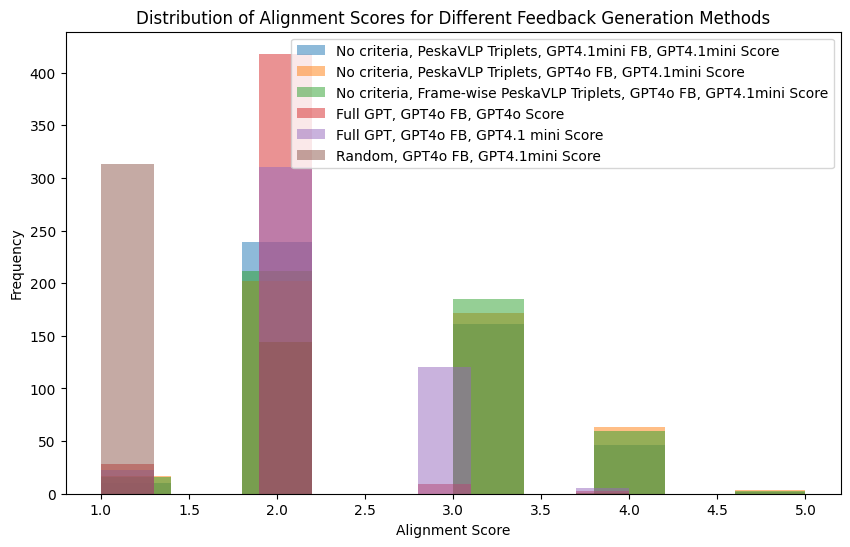

In [8]:
import matplotlib.pyplot as plt

rows = []

plt.figure(figsize=(10, 6))
for name, fb_alignment_path in [
    # ('Base', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP.csv'),
    # ('Optional Urgency+Reflection', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-no_2_6_criteria.csv'),
    ('No criteria, PeskaVLP Triplets, GPT4.1mini FB, GPT4.1mini Score', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-no_criteria.csv'),
    # ('Short', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-short.csv'),
    # ('No criteria + examples', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-no_criteria-examples.csv'),
    # ('No criteria + history', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-no_criteria-history.csv'),
    # ('No criteria (gpt4o)', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-gpt4o-no_criteria.csv'),
    ('No criteria, PeskaVLP Triplets, GPT4o FB, GPT4.1mini Score', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-gpt4o_with_gpt41mini_scoring-no_criteria.csv'),
    ('No criteria, Frame-wise PeskaVLP Triplets, GPT4o FB, GPT4.1mini Score', '../outputs/fb_generation/fb_alignment_df_frame-vl_both-PeskaVLP-gpt4o_with_gpt41mini_scoring-no_criteria.csv'),
    ('Full GPT, GPT4o FB, GPT4o Score', '../outputs/fb_generation/fb_alignment_df-full_gpt-gpt4o-no_criteria.csv'),
    ('Full GPT, GPT4o FB, GPT4.1 mini Score', '../outputs/fb_generation/fb_alignment_df-full_gpt-gpt4o_with_gpt41mini_scoring-no_criteria.csv'),
    ('Random, GPT4o FB, GPT4.1mini Score', '../outputs/fb_generation/fb_alignment_df_random-full_gpt-gpt4o_with_gpt41mini_scoring-no_criteria.csv'),
    # ('No criteria (gpt4o) + history', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-gpt4o-no_criteria-history.csv'),
    # ('No criteria + history + examples', '../outputs/fb_generation/fb_alignment_df-vl_both-PeskaVLP-no_criteria-history-examples.csv'),
]:
    fb_alignment_df = pd.read_csv(fb_alignment_path)
    plt.hist(fb_alignment_df['alignment_score'], bins=10, alpha=0.5, label=name)
    plt.legend()
    
    rows.append({
        'Condition': f'{name}',
        'Mean': fb_alignment_df['alignment_score'].mean(),
        'Median': fb_alignment_df['alignment_score'].median(),
        '% >= 3': (fb_alignment_df['alignment_score'] >= 3).mean() * 100,
        '% at 1': (fb_alignment_df['alignment_score'] == 1).mean() * 100,
        'N': len(fb_alignment_df),
    })
    
    print('='*100)
    print(f"Name: {name}")
    for i, example_num in enumerate([94]):
        print(f"Example {i + 1}, 'Dialogue': {fb_alignment_df['Dialogue'].iloc[example_num]}")
        print(f"IAT(instrument: {fb_alignment_df['instrument-label'].iloc[example_num]}, action: {fb_alignment_df['action-label'].iloc[example_num]}, tissue: {fb_alignment_df['tissue-label'].iloc[example_num]})")
        print(f"Generated Feedback: {fb_alignment_df['generated_feedback'].iloc[example_num]}")
        print(f"Alignment Score: {fb_alignment_df['alignment_score'].iloc[example_num]}")
        print()
    print('='*100)

plt.xlabel('Alignment Score')
plt.ylabel('Frequency')
plt.title('Distribution of Alignment Scores for Different Feedback Generation Methods')
plt.show()

In [9]:
fb_alignment_df['Dialogue'].tolist().index("no, open the superficial layer first")

193

In [10]:
fb_alignment_df[fb_alignment_df['alignment_score'] == 5]

,Dialogue,Timestamp,Case,instrument-label,instrument-pred,instrument-correct,action-label,action-pred,action-correct,tissue-label,tissue-pred,tissue-correct,cvid,valid,generated_feedback,alignment_score


In [11]:
analysis_df = pd.DataFrame(rows)
analysis_df.round(3)

,Condition,Mean,Median,% >= 3,% at 1,N
0,"No criteria, PeskaVLP Triplets, GPT4.1mini FB,...",2.544,2.0,45.633,2.183,458
1,"No criteria, PeskaVLP Triplets, GPT4o FB, GPT4...",2.640,3.0,52.183,3.712,458
2,"No criteria, Frame-wise PeskaVLP Triplets, GPT...",2.626,3.0,52.101,3.361,476
3,"Full GPT, GPT4o FB, GPT4o Score",1.972,2.0,2.620,6.114,458
4,"Full GPT, GPT4o FB, GPT4.1 mini Score",2.234,2.0,27.293,5.022,458
5,"Random, GPT4o FB, GPT4.1mini Score",1.321,1.0,0.218,68.341,458
